D)

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MultipleLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import _LinearRegression
import OLS

import seaborn as sns

In [4]:
def Runge_func(x):
    return 1.0/(1 + 25*x**2)

In [ ]:
np.random.seed(2025)

n = 1000
x = np.linspace(-1, 1, n)

std = 0.1
y = Runge_func(x) + np.random.normal(0, std, size=n)

degree = 12

x = x.reshape(-1, 1)
y = y.reshape(-1,1)

X = PolynomialFeatures(degree, include_bias=False).fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Add bias manually, for OLS fit
X_train_s_bias = np.hstack([np.ones((X_train_s.shape[0], 1)), X_train_s])
X_test_s_bias = np.hstack([np.ones((X_test_s.shape[0], 1)), X_test_s])

scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_s = scaler_y.transform(y_train)
y_test_s = scaler_y.transform(y_test)

In [ ]:
strr = "sigmoid"
func_name = strr
func = globals()[func_name]  # or locals()[func_name]


np.float64(0.9820137900379085)

In [41]:
[sigmoid]*2 + [id_func]

[<function functions.sigmoid(x)>,
 <function functions.sigmoid(x)>,
 <function functions.id_func(x)>]

In [ ]:
# Fine best batch and epoch size

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

num_hlayers_configs = [1,2,3]
name_activation_funcs = [sigmoid, ReLU, leaky_ReLU]
name_activation_funcs_der = [sigmoid_der, ReLU_der, leaky_ReLU_der]

batch_size = 8
epochs = 100

MSE_FFNN_configs_test_matrix = np.zeros([len(num_hlayers_configs), len(name_activation_funcs)])

for i in range(len(num_hlayers_configs)):

    for j in range(len(name_activation_funcs)):
        # np.random.seed(2025)

        # Build number of nodes per hidden layer
        n_hl_nodes = num_hlayers_configs[i]

        if n_hl_nodes > 1:
            num_nodes = [100]*n_hl_nodes
        else:
            num_nodes = [200]
        
        # Build list with activation functions per hidden layer
        activation_funcs_config = [name_activation_funcs[j]]*n_hl_nodes + [id_func]
        activation_funcs_der_config = [name_activation_funcs_der[j]]*n_hl_nodes + [id_func_der]

        scheduler = Adam(0.001)

        # Setting up FFNN, important do to this for each iterations so we can match with seed later
        ffnn = NeuralNetwork(n_inputs=num_input_feats, 
                        n_outputs=num_output_feats,
                        n_nodes_hidden_layers=num_nodes,
                        activation_funcs=activation_funcs_config,
                        activation_derivs=activation_funcs_der_config,
                        scheduler=scheduler,
                        cost_func=mse,
                        cost_func_der=mse_der, 
                        regularization = None,
                        reg_param=0,
                        seed=2025)
        

        #Train
        ffnn.train(X_train_s[:, 0].reshape(-1,1), y_train_s, batch_size, epochs)
        
        test_pred = ffnn.predict(X_test_s[:, 0].reshape(-1,1))
        
        test_pred = scaler_y.inverse_transform(test_pred)

        MSE_FFNN_configs_test_matrix[i,j] = mean_squared_error(test_pred, y_test)

        print(i,j)

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2


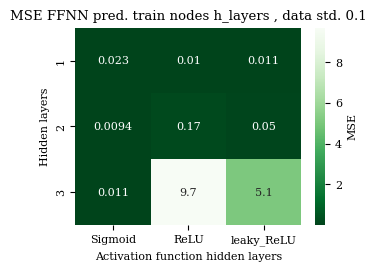

In [77]:
MM_TO_INCH = 1/25.4

matplotlib.rc("text", usetex=False)
plt.rc('lines', linewidth=1.0)
plt.rc("figure", autolayout=True)
plt.rc("legend", fontsize=6)
plt.rc("font", family="serif", size=8)
plt.figure(figsize=(86.78*MM_TO_INCH, 70*MM_TO_INCH))
# # plt.ticklabel_format(axis = "y", style="sci")
# # plt.gca().xaxis.set_major_locator(MultipleLocator(base=1, offset=1))   # Configure the markers on the x axis
# # plt.grid(True, which="both", linestyle="--", linewidth=0.25)

activation_labels = ["Sigmoid", "ReLU", "leaky_ReLU"]

sns.heatmap(MSE_FFNN_configs_test_matrix, annot=True, cmap="Greens_r",
            xticklabels=activation_labels, yticklabels=num_hlayers_config, cbar_kws={"label": "MSE"}, fmt=".2g"
            )
plt.xlabel("Activation function hidden layers")
plt.ylabel("Hidden layers")
plt.title(f"MSE FFNN pred. train nodes h_layers , data std. {std}")
# plt.savefig("heatmap_MSE_lr_opti_FFNN_100_100.pdf", bbox_inches="tight")
plt.show()
plt.close()

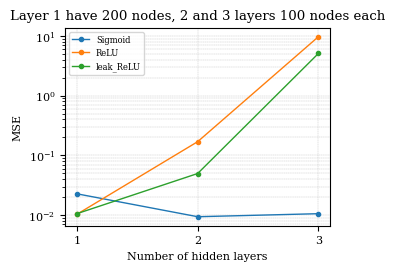

In [99]:
matplotlib.rc("text", usetex=False)
plt.rc('lines', linewidth=1.0)
plt.rc("figure", autolayout=True)
plt.rc("legend", fontsize=6)
plt.rc("font", family="serif", size=8)
plt.figure(figsize=(86.78*MM_TO_INCH, 70*MM_TO_INCH))
# plt.ticklabel_format(axis = "y", style="sci")
plt.gca().xaxis.set_major_locator(MultipleLocator(base=1, offset=0))   # Configure the markers on the x axis
plt.grid(True, which="both", linestyle="--", linewidth=0.25)

plt.semilogy(num_hlayers_config, MSE_FFNN_configs_test_matrix[:,0], ".-", label="Sigmoid")
plt.semilogy(num_hlayers_config, MSE_FFNN_configs_test_matrix[:,1], ".-", label="ReLU")
plt.semilogy(num_hlayers_config, MSE_FFNN_configs_test_matrix[:,2], ".-", label="leak_ReLU")
plt.xlabel("Number of hidden layers")
plt.ylabel("MSE")
plt.title("Layer 1 have 200 nodes, 2 and 3 layers 100 nodes each")
plt.legend()
plt.plot()
plt.show()